# HHL oracle sweep on 4×4 instances

Benchmarks the three eigenvalue-inversion oracles (`MCRYEigOracle`, `UCRYEigOracle`, `ExactReciprocalEigOracle`) on a set of 4×4 linear systems while sweeping the number of QPE qubits `m`.

Two metrics per `(instance, oracle, m)` triple:

1. **Log relative residual** `‖A·α·x_hhl − b‖ / ‖b‖`, where `x_hhl` is the unit-norm post-selected HHL data-register state and `α` is the optimal scalar that minimises the residual.
2. **Decomposed circuit depth** of the full HHL circuit (state prep + forward QPE + inversion + ancilla measurement + inverse QPE).

The instance set spans condition numbers from 2 to 20 plus one indefinite spectrum, exercising both the SPD path (`neg_vals=False` on the quantum oracle, no two's-complement unwrap on classical/unary) and the indefinite path.

In [41]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists():
            return d
    return p

repo_root = find_repo_root()
src_dir = repo_root / "src"
for d in (src_dir, repo_root):
    if str(d) not in sys.path:
        sys.path.insert(0, str(d))

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from qlsas.algorithms.hhl import HHL, MCRYEigOracle, ExactReciprocalEigOracle, UCRYEigOracle
from qlsas.state_prep import DefaultStatePrep

%config InlineBackend.figure_format = "retina"
plt.rcParams.update({"font.size": 11})

## Configuration

Adjust the problem size `N` (must be a power of 2) and the list of QPE register sizes `M_VALUES`.  Statevector simulation runs on `1 + max(M_VALUES) + log2(N)` qubits — keep that under ~14 to stay fast on a laptop.

In [43]:
N = 8                          # problem size (must be a power of 2)
M_VALUES = list(range(2, 8))   # QPE qubit counts to sweep

import math
assert N > 0 and (N & (N - 1)) == 0, "N must be a power of 2"
n_data = int(math.log2(N))
total_qubits = 1 + max(M_VALUES) + n_data
print(f"problem size:    {N}×{N}  (n_data={n_data} qubits)")
print(f"QPE sweep:       m in {M_VALUES}")
print(f"sim Hilbert dim: 2^{total_qubits} = {2**total_qubits}")

problem size:    8×8  (n_data=3 qubits)
QPE sweep:       m in [2, 3, 4, 5, 6, 7]
sim Hilbert dim: 2^11 = 2048


## 1. Instances

In [44]:
def random_spd(n, cond, seed):
    rng = np.random.default_rng(seed)
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    eigs = np.linspace(1.0, cond, n)
    return (Q * eigs) @ Q.T

def random_indefinite(n, seed):
    """Hermitian matrix with a balanced indefinite spectrum."""
    n_neg = n // 2
    eigs_neg = np.linspace(-2.0, -0.5, n_neg)
    eigs_pos = np.linspace(1.0, 3.0, n - n_neg)
    eigs = np.concatenate([eigs_neg, eigs_pos])
    rng = np.random.default_rng(seed)
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    return (Q * eigs) @ Q.T

def random_b(n, seed):
    rng = np.random.default_rng(seed)
    v = rng.standard_normal(n)
    return v / np.linalg.norm(v)

INSTANCES = [
    ("SPD κ=2",    random_spd(N, 2.0, 0),  random_b(N, 100)),
    ("SPD κ=5",    random_spd(N, 5.0, 1),  random_b(N, 101)),
    ("SPD κ=10",   random_spd(N, 10.0, 2), random_b(N, 102)),
    ("SPD κ=20",   random_spd(N, 20.0, 3), random_b(N, 103)),
    ("Indefinite", random_indefinite(N, 4), random_b(N, 104)),
]

for name, A, b in INSTANCES:
    eigs = np.sort(np.linalg.eigvalsh(A))
    print(f"{name:14s} cond={np.linalg.cond(A):6.2f}  eigs={np.round(eigs, 3)}")

SPD κ=2        cond=  2.00  eigs=[1.    1.143 1.286 1.429 1.571 1.714 1.857 2.   ]
SPD κ=5        cond=  5.00  eigs=[1.    1.571 2.143 2.714 3.286 3.857 4.429 5.   ]
SPD κ=10       cond= 10.00  eigs=[ 1.     2.286  3.571  4.857  6.143  7.429  8.714 10.   ]
SPD κ=20       cond= 20.00  eigs=[ 1.     3.714  6.429  9.143 11.857 14.571 17.286 20.   ]
Indefinite     cond=  6.00  eigs=[-2.    -1.5   -1.    -0.5    1.     1.667  2.333  3.   ]


## 2. Helpers

* `hhl_post_selected_state` simulates the full HHL circuit, strips the mid-circuit ancilla measurement, and post-selects on `(ancilla=1, qpe=|0⟩)` to recover the unit-norm data register.
* `relative_residual` finds the optimal scalar `α` so that comparing to the classical solution is sign- and norm-invariant.
* `full_hhl_depth` returns the depth of `qlsa_circuit.circuit.decompose()` — one decomposition pass, matching the convention in the other notebooks.

In [45]:
def _strip_measurements(circ):
    qc = QuantumCircuit(*circ.qregs)
    for inst in circ.data:
        if inst.operation.name in ("measure", "reset"):
            continue
        qc.append(inst.operation, inst.qubits)
    return qc


def _decompose_to_fixpoint(circ, max_reps=10):
    """Repeat ``circ.decompose()`` until the gate-count signature stops changing.

    Single-call ``.decompose()`` only unrolls one wrapper layer.  The Quantum
    oracle's ``ExactReciprocalGate`` wraps a UCRY which wraps another block,
    and each of those intermediate forms is a single-instruction circuit of
    depth 1 — so a depth-stability check exits prematurely.  Comparing
    ``count_ops()`` instead avoids that trap.
    """
    prev_ops = None
    for _ in range(max_reps):
        ops = tuple(sorted(circ.count_ops().items()))
        if ops == prev_ops:
            break
        prev_ops = ops
        circ = circ.decompose()
    return circ


def hhl_post_selected_state(A, b, m, eig_oracle):
    n_data = int(np.log2(len(b)))
    sp = DefaultStatePrep()
    hhl = HHL(num_qpe_qubits=m, eig_oracle=eig_oracle)
    qlsa_circuit = hhl.build_circuit(A, b, sp)

    sv = Statevector.from_instruction(_strip_measurements(qlsa_circuit.circuit)).data
    # Qubit order: ancilla(1) | qpe(m) | data(n_data); statevector is little-endian,
    # so qubit 0 (ancilla) is the LSB of the index.
    x = np.array([sv[1 + (d << (1 + m))] for d in range(2**n_data)])
    n = np.linalg.norm(x)
    return x / n if n > 1e-15 else x


def relative_residual(A, b, x_norm):
    Ax = A @ x_norm
    denom = float(np.real(np.vdot(Ax, Ax)))
    if denom < 1e-30:
        return 1.0
    alpha = float(np.real(np.vdot(Ax, b)) / denom)
    return float(np.linalg.norm(A @ (alpha * x_norm) - b) / np.linalg.norm(b))


def full_hhl_depth(A, b, m, eig_oracle):
    sp = DefaultStatePrep()
    hhl = HHL(num_qpe_qubits=m, eig_oracle=eig_oracle)
    circ = hhl.build_circuit(A, b, sp).circuit
    return _decompose_to_fixpoint(circ).depth()

## 3. Sweep

In [ ]:
ORACLES = {
    "MCRY":             MCRYEigOracle,
    "UCRY":             UCRYEigOracle,
    "ExactReciprocal":  ExactReciprocalEigOracle,
}

n_inst = len(INSTANCES)
n_m = len(M_VALUES)

residuals = {label: np.full((n_inst, n_m), np.nan) for label in ORACLES}
depths    = {label: np.full((n_inst, n_m), np.nan) for label in ORACLES}

for i, (inst_name, A, b) in enumerate(INSTANCES):
    print(f"\n=== {inst_name} ===")
    for j, m in enumerate(M_VALUES):
        line = []
        for label, oracle_cls in ORACLES.items():
            x_norm = hhl_post_selected_state(A, b, m, oracle_cls())
            res = relative_residual(A, b, x_norm)
            d   = full_hhl_depth(A, b, m, oracle_cls())
            residuals[label][i, j] = res
            depths[label][i, j]    = d
            line.append(f"{label}: res={res:.2e} d={d}")
        print(f"  m={m}  " + "  ".join(line))

## 4. Log residual vs QPE qubits

One panel per instance.  Lines per oracle.  `y`-axis is log scale; the residual floor at large `m` reflects how well a given oracle’s rotation schedule approximates `1/λ` for the actual spectrum.

In [ ]:
MARKERS = {"MCRY": "o", "UCRY": "s", "ExactReciprocal": "D"}
COLORS  = {"MCRY": "C0", "UCRY": "C1", "ExactReciprocal": "C2"}

fig, axes = plt.subplots(1, n_inst, figsize=(3.6 * n_inst, 4), sharey=True)

for i, (inst_name, A, b) in enumerate(INSTANCES):
    ax = axes[i]
    for label in ORACLES:
        ax.plot(
            M_VALUES, residuals[label][i],
            marker=MARKERS[label], color=COLORS[label],
            label=label, linewidth=1.6,
        )
    ax.set_yscale("log")
    ax.set_xlabel("QPE qubits (m)")
    ax.set_title(inst_name, fontsize=11)
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel(r"Relative residual  $\|A\,\alpha\,x - b\|\,/\,\|b\|$")
axes[-1].legend(loc="best", fontsize=9)
fig.suptitle(f"HHL log residual vs QPE qubits  ({N}×{N} instances)", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

## 5. Circuit depth vs QPE qubits

Depth is essentially instance-independent for a fixed `(oracle, m)` shape — the gate structure depends only on `m` and `n_data`, not on the rotation angles.  Faint lines show per-instance depth; bold lines show the mean across instances.

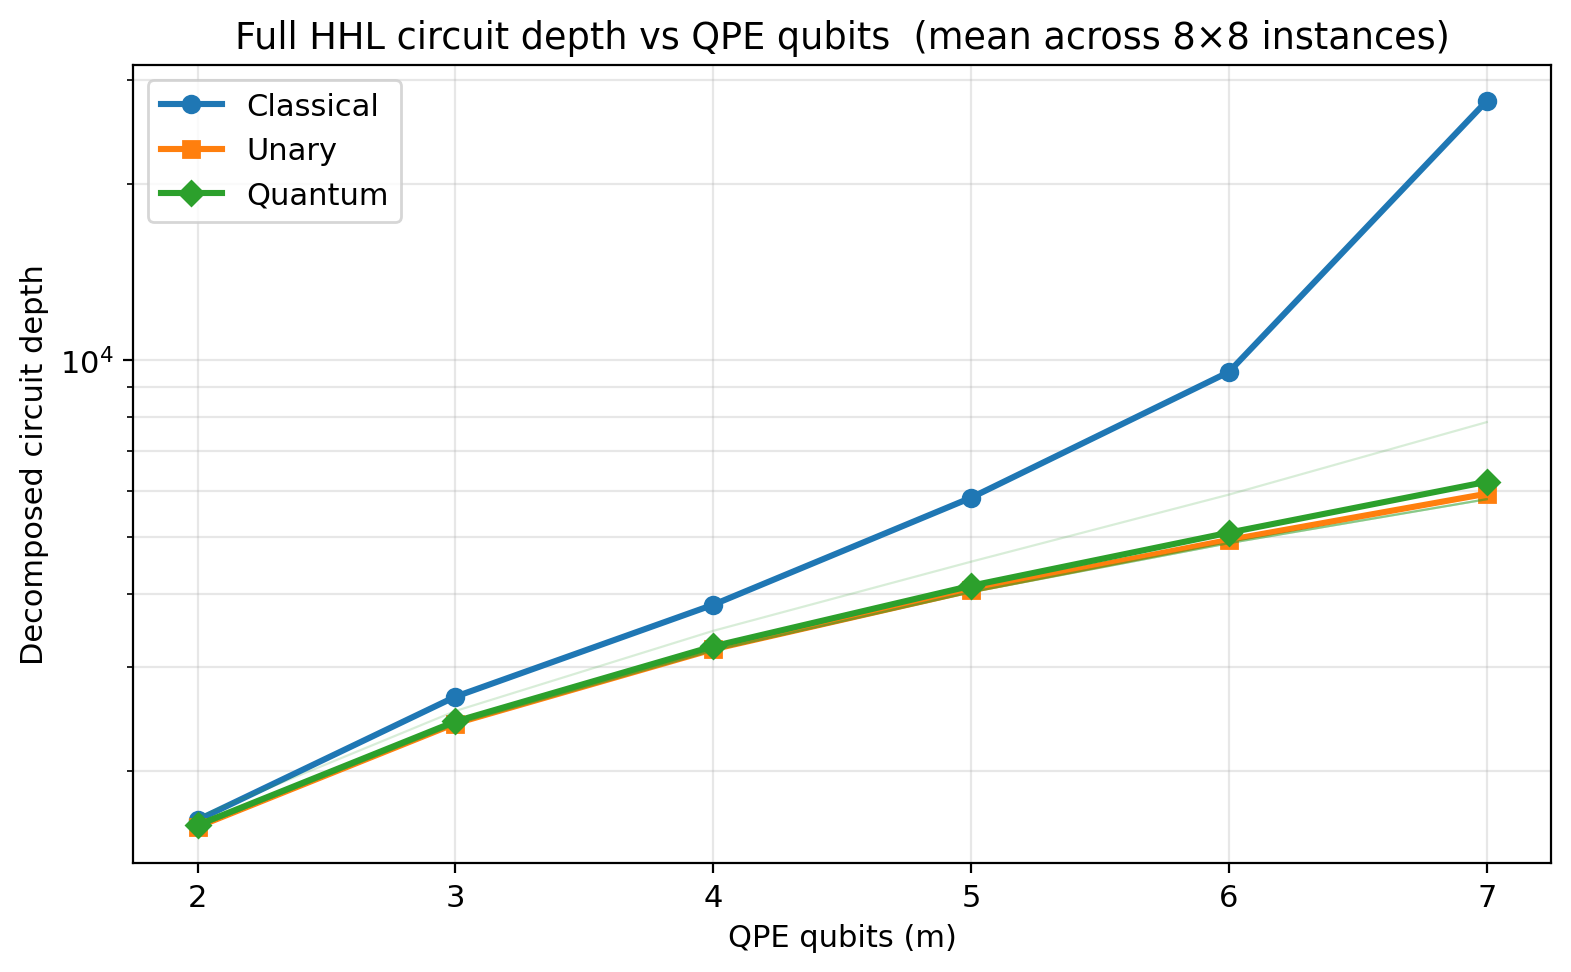

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))

for label in ORACLES:
    for i in range(n_inst):
        ax.plot(M_VALUES, depths[label][i], color=COLORS[label], alpha=0.18, linewidth=0.8)
    mean = depths[label].mean(axis=0)
    ax.plot(
        M_VALUES, mean,
        marker=MARKERS[label], color=COLORS[label],
        label=label, linewidth=2.2,
    )

ax.set_xlabel("QPE qubits (m)")
ax.set_ylabel("Decomposed circuit depth")
ax.set_yscale("log")
ax.set_title(f"Full HHL circuit depth vs QPE qubits  (mean across {N}×{N} instances)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 6. Notes

* **MCRY and UCRY residuals are identical** for every `(instance, m)` pair — by construction they implement the same rotation table, just with different gate decompositions (multi-controlled RY vs UCRy tree).  Any visible difference is floating-point noise.
* **ExactReciprocal residual** can drift from the other two.  Qiskit's `ExactReciprocalGate` skips states where `|S · nl / i| > 1` (returns `angle = 0`) and hard-codes `angles_neg[0] = 0`, so the most-negative-phase boundary state on indefinite spectra is never inverted.  At low `m` these missing rotations matter; at large `m` they sit on negligible-amplitude states and the three oracles converge.
* **Depth ordering** is `MCRY ≫ UCRY ≈ ExactReciprocal`.  UCRY and ExactReciprocal scale the same way — `O(2^m)` — because Qiskit's `ExactReciprocalGate` decomposes to a `UCRYGate` which in turn decomposes to the same Möttönen-style tree as `UCRYEigOracle`.  ExactReciprocal is ~10–20% shallower in absolute terms (constant-factor advantage from Qiskit's angle ordering), not asymptotically shallower.

See `docs/eigenvalue_inversion.md` for the full algorithmic comparison and decision guide.